# Lecture 4: Data Representations for SciML

The same physical field can be stored in many ways. Each choice decides what a model sees and what it has to learn.
Three parts, one for each part of today's lecture:

1. **Resolution**: downsample BubbleML frames from 512 × 512 to 64 × 64 by keeping every 8th value and by averaging, and compare their spectra.
2. **POD**: compute the modes of the heat data and of BubbleML temperature and reconstruct frames with a few modes.
3. **Predicting the change**: retrain the Lecture 1 `SmallCNN` on the heat data with a standardized increment and compare rollouts.

In [1]:
import os
import urllib.request
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
rng = np.random.default_rng(0)

# the Lecture 1 BubbleML files (downloaded again if missing)
DATA_DIR = "../data/bubbleml"
URL = "https://raw.githubusercontent.com/HPCForge/BubbleML/main/examples/"
os.makedirs(DATA_DIR, exist_ok=True)
for f in ["Twall-100.hdf5", "Twall-106.hdf5"]:
    if not os.path.exists(os.path.join(DATA_DIR, f)):
        print("downloading", f)
        urllib.request.urlretrieve(URL + f, os.path.join(DATA_DIR, f))

# temperature colormap from Lecture 1 (https://github.com/therml-ai/boiling-viz), for nondimensional temperature in [0, 1]
from matplotlib.colors import LinearSegmentedColormap
temp_cmap = LinearSegmentedColormap.from_list("temp_green", list(zip(
    [0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.134, 0.167, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    ["#0000FF", "#0443FF", "#0E7AFF", "#16B4FF", "#1FF1FF", "#21FFD3", "#22FF9B", "#22FF67", "#22FF15", "#29FF06",
     "#45FF07", "#6DFF08", "#9EFF09", "#D4FF0A", "#FEF30A", "#FEB709", "#FD7D08", "#FC4908", "#FC1407", "#FB0007"])))

def load_temperature(twall):
    with h5py.File(os.path.join(DATA_DIR, f"Twall-{twall}.hdf5"), "r") as f:
        return f["temperature"][:].astype(np.float64)       # (time, y, x), nondimensional, 0 = bulk liquid, 1 = heater

temp106 = load_temperature(106)
print("Twall = 106 °C temperature:", temp106.shape)

Using device: mps
Twall = 106 °C temperature: (201, 48, 48)


---
## Part 1: Downsampling, by keeping values or by averaging

For this part we use 25 temperature frames from BubbleML_2 at full resolution, 512 × 512
(Twall = 106 °C, t = 150 to 169, 0.8 apart, stored as nondimensional temperature in float16).
The file `bubbleml2_Twall106_512_t150-170.npz` is in the course `data/bubbleml` folder.

We reduce each frame to 64 × 64 in two ways:

* **stride**: keep one value from each 8 × 8 block of cells, `u[o::8, o::8]`. There are 8 choices of the offset `o` in each direction.
* **average**: replace each 8 × 8 block by its mean.

Recall Nyquist from the lecture: a 64 × 64 grid can represent wavenumbers up to 32.
Anything finer in the 512 × 512 field has to go somewhere.

BubbleML_2 temperature: (25, 512, 512)   times 150.0 to 169.20000000000002


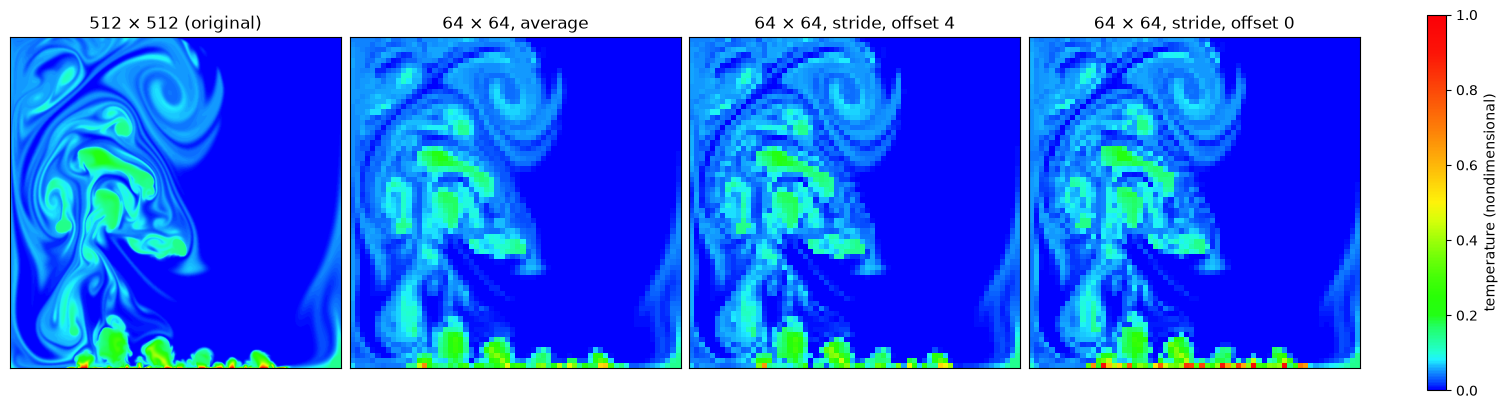

In [2]:
hires = np.load(os.path.join(DATA_DIR, "bubbleml2_Twall106_512_t150-170.npz"))
temp512 = hires["temperature"].astype(np.float64)        # (25, 512, 512)
print("BubbleML_2 temperature:", temp512.shape, "  times", hires["t"][0], "to", hires["t"][-1])

f = 8                       # downsampling factor: 512 -> 64
n_coarse = 512 // f

def stride(u, offset):
    return u[..., offset::f, offset::f]

def average(u):
    return u.reshape(*u.shape[:-2], n_coarse, f, n_coarse, f).mean(axis=(-3, -1))

t = 12
panels = [(temp512[t], "512 × 512 (original)"),
          (average(temp512[t]), "64 × 64, average"),
          (stride(temp512[t], 4), "64 × 64, stride, offset 4"),
          (stride(temp512[t], 0), "64 × 64, stride, offset 0")]
fig, axes = plt.subplots(1, 4, figsize=(15, 4), layout="constrained")
for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, cmap=temp_cmap, vmin=0, vmax=1, origin="lower")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="temperature (nondimensional)")
plt.show()

The strided frames look sharper than the average, with thin plumes and bubble edges kept as single bright or dark cells.
Offset 0 keeps the bottom row of cells, the thin hot layer on the heater, so the bottom row of the coarse grid is hotter than in the average.

To see where the difference comes from, compare **energy spectra**: for each wavenumber $k$, the energy of the Fourier modes with $|k| \approx k$
(the same radially summed $|\mathrm{FFT}|^2$ as on the slide), averaged over the 25 frames.
As on the slide, we plot the energy of each 64 × 64 version divided by the energy of the 512 × 512 original at the same wavenumber.
A ratio of 1 means that wavenumber is kept as it was.

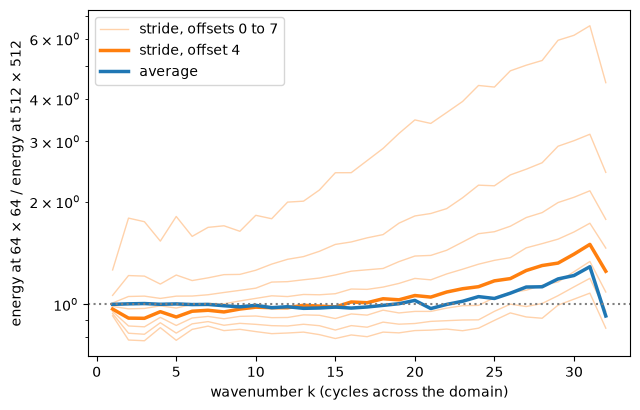

share of the energy above k = 32 in the original: 15%


In [3]:
def spectrum(u):
    # radially summed |FFT|^2 per integer wavenumber, averaged over frames; u has shape (frames, n, n)
    n = u.shape[-1]
    uhat = np.fft.fft2(u - u.mean(axis=(-2, -1), keepdims=True)) / n**2
    energy = np.abs(uhat)**2
    k = np.fft.fftfreq(n) * n
    kx, ky = np.meshgrid(k, k)
    kr = np.rint(np.hypot(kx, ky)).astype(int)
    return np.array([energy[:, kr == j].sum(axis=-1).mean() for j in range(n // 2 + 1)])

E_full = spectrum(temp512)
k = np.arange(1, n_coarse // 2 + 1)
ratio = lambda E: E[1:] / E_full[1:n_coarse // 2 + 1]

plt.figure(figsize=(7, 4.5))
for o in range(f):
    plt.plot(k, ratio(spectrum(stride(temp512, o))), color="tab:orange", lw=1, alpha=0.35,
             label="stride, offsets 0 to 7" if o == 0 else None)
plt.plot(k, ratio(spectrum(stride(temp512, 4))), color="tab:orange", lw=2.5, label="stride, offset 4")
plt.plot(k, ratio(spectrum(average(temp512))), color="tab:blue", lw=2.5, label="average")
plt.axhline(1, color="gray", ls=":")
plt.yscale("log")
plt.xlabel("wavenumber k (cycles across the domain)"); plt.ylabel("energy at 64 × 64 / energy at 512 × 512")
plt.legend(); plt.show()


print(f"share of the energy above k = {n_coarse // 2} in the original: {E_full[n_coarse // 2 + 1:].sum() / E_full[1:].sum():.0%}")

**What to observe**

* The average stays close to 1 up to about $k = 20$, then rises to about 1.25 just below the Nyquist wavenumber, 32.
  An 8 × 8 block average is a simple low-pass filter: it removes most of the energy above 32, and lets a little of what lies just above 32 through.
* The strided spectra rise above 1 toward $k = 32$. That extra energy came from wavenumbers above 32, which the 64 × 64 grid cannot hold,
  so it folds back onto lower wavenumbers (aliasing).
* How much folds back depends on the offset, that is, which cell of each block you happen to keep. Offset 0 sits on the heater row and is far off;
  some offsets fall below 1. The average has one spectra.

---
## Part 2: POD of the heat data and of BubbleML

Recall from the lecture: the snapshots, minus their mean, form the columns of a matrix $X$. Compute the SVD,

$$X = [\,u_1 - \bar u,\; \dots,\; u_N - \bar u\,] = U \Sigma V^\top .$$

The columns of $U$ are the POD modes $\varphi_k$, and the singular values $\sigma_k$ indicate how much each mode contributes.
To compress a field, keep the first $r$ modes $U_r$:

$$a = U_r^\top (u - \bar u), \qquad \hat u = \bar u + U_r\, a .$$


heat      250 snapshots:  90% of the energy needs   2 modes,  99% needs   4
BubbleML  200 snapshots:  90% of the energy needs  51 modes,  99% needs 147


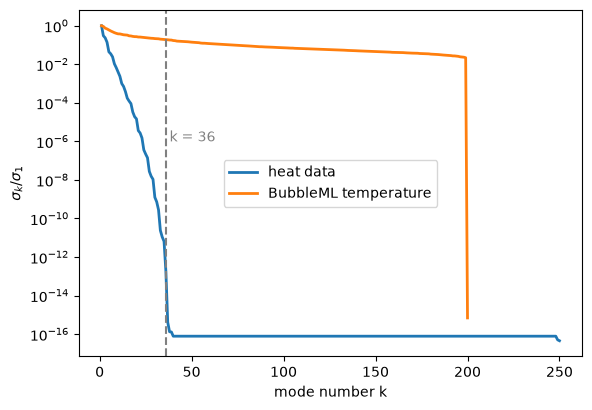

In [4]:
N, alpha, dt, T, K = 48, 1.0, 5e-4, 100, 6       # same settings as Lecture 1
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)

def heat_trajectory(K=K):
    u = np.zeros((T + 1, N, N))
    t = np.arange(T + 1)[:, None, None] * dt
    for m in range(1, K + 1):
        for n in range(1, K + 1):
            a = rng.normal() / (m**2 + n**2)
            u += a * np.sin(m * np.pi * X) * np.sin(n * np.pi * Y) * np.exp(-alpha * np.pi**2 * (m**2 + n**2) * t)
    return u

heat_train64 = np.stack([heat_trajectory() for _ in range(100)])      # same seed and order as Lecture 1
heat_test64 = np.stack([heat_trajectory() for _ in range(20)])
heat_train, heat_test = heat_train64.astype(np.float32), heat_test64.astype(np.float32)

def pod(snapshots):
    # snapshots: (count, ny, nx). Returns mean, modes U (columns), singular values S
    Xs = snapshots.reshape(len(snapshots), -1).T
    mean = Xs.mean(axis=1, keepdims=True)
    U, S, _ = np.linalg.svd(Xs - mean, full_matrices=False)
    return mean[:, 0], U, S

heat_snap = heat_train64[:3, 1:].reshape(-1, N, N)[:250]     # 250 consecutive frames from 3 trajectories (as on the slide)
bubble_snap = temp106[1:]                                     # 200 frames, 1.0 apart
heat_mean, heat_U, heat_S = pod(heat_snap)
bubble_mean, bubble_U, bubble_S = pod(bubble_snap)

def modes_for(S, frac):
    energy = np.cumsum(S**2) / np.sum(S**2)
    return int(np.searchsorted(energy, frac) + 1)

for name, S in [("heat", heat_S), ("BubbleML", bubble_S)]:
    print(f"{name:9s} {len(S)} snapshots:  90% of the energy needs {modes_for(S, 0.9):3d} modes,  99% needs {modes_for(S, 0.99):3d}")

plt.figure(figsize=(6.5, 4.5))
plt.semilogy(np.arange(1, len(heat_S) + 1), heat_S / heat_S[0], lw=2, label="heat data")
plt.semilogy(np.arange(1, len(bubble_S) + 1), bubble_S / bubble_S[0], lw=2, label="BubbleML temperature")
plt.axvline(36, color="gray", ls="--"); plt.text(38, 1e-6, "k = 36", color="gray")
plt.xlabel("mode number k"); plt.ylabel(r"$\sigma_k / \sigma_1$"); plt.legend(); plt.show()

**What to observe**

* The heat data reach round-off after 36 modes. Every snapshot is a combination of the $6 \times 6$ sine modes $\sin(m\pi x)\sin(n\pi y)$, $m, n \le 6$, so the snapshots span 36 dimensions at most.
* The BubbleML singular values fall slowly. Bubbles and plumes move, and a moving feature needs many fixed modes.
  The drop at the end is the number of snapshots: 200 snapshots minus their mean span at most 199 dimensions.

Now reconstruct one frame of each (a frame from the snapshot set) with $r = 5$, $20$ and $50$ modes.

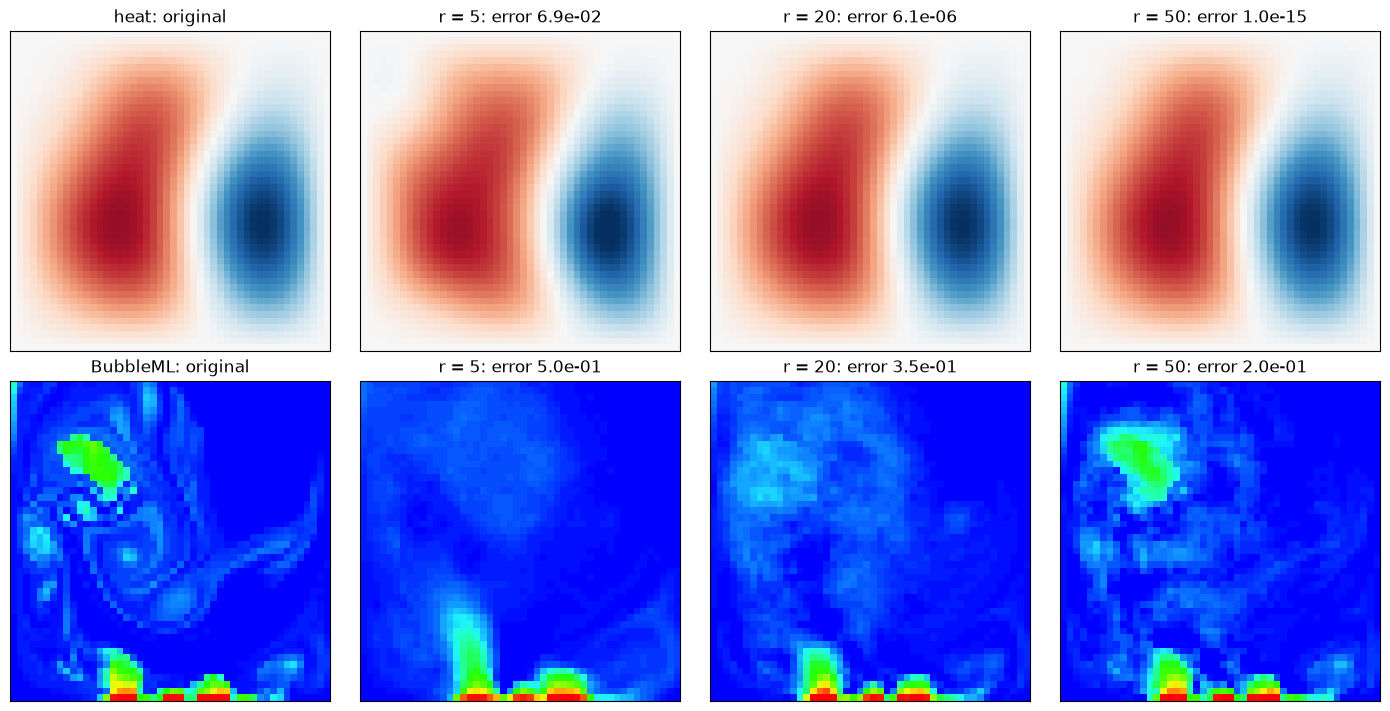

In [5]:
def reconstruct(u, mean, U, r):
    a = U[:, :r].T @ (u.ravel() - mean)            # r coefficients
    return (mean + U[:, :r] @ a).reshape(u.shape)

def relative_error(pred, true):
    return np.linalg.norm(pred - true) / np.linalg.norm(true)

ranks = [5, 20, 50]
cases = [("heat", heat_snap[30], heat_mean, heat_U, "RdBu_r"),
         ("BubbleML", bubble_snap[100], bubble_mean, bubble_U, temp_cmap)]
fig, axes = plt.subplots(2, len(ranks) + 1, figsize=(14, 7), layout="constrained")
for row, (name, u, mean, U, cmap) in enumerate(cases):
    lo, hi = (-np.abs(u).max(), np.abs(u).max()) if name == "heat" else (0, 1)
    axes[row, 0].imshow(u, cmap=cmap, vmin=lo, vmax=hi, origin="lower")
    axes[row, 0].set_title(f"{name}: original")
    for col, r in enumerate(ranks, start=1):
        rec = reconstruct(u, mean, U, r)
        axes[row, col].imshow(rec, cmap=cmap, vmin=lo, vmax=hi, origin="lower")
        axes[row, col].set_title(f"r = {r}: error {relative_error(rec, u):.1e}")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

**What to observe:** the heat frame is exact to round-off once $r \ge 36$, while the BubbleML frame still shows a visible error with 50 modes.
POD works well when the data lie near a low-dimensional linear subspace and poorly when features move.

---
## Part 3: Predicting a standardized increment

In Lecture 1, `SmallCNN.forward` returned `x[:, :1] + self.net(x)`: the current field plus a learned change.
That is forward Euler with a learned right-hand side and the network is trained on the increment $\Delta u = u_{n+1} - u_n$.

How big is that increment compared with the field?

In [6]:
du = heat_train[:, 1:] - heat_train[:, :-1]
mu_u, sigma_u = heat_train[:, :-1].mean(), heat_train[:, :-1].std()
mu_du, sigma_du = du.mean(), du.std()
print(f"u : mean {mu_u:+.2e}   std {sigma_u:.2e}")
print(f"Δu: mean {mu_du:+.2e}   std {sigma_du:.2e}   ({sigma_du / sigma_u:.1%} of the std of u)")

u : mean -4.12e-03   std 1.73e-01
Δu: mean +5.23e-05   std 3.59e-03   (2.1% of the std of u)


The network has to output values about 50 times smaller than its input. We standardize the input with $\mu_u, \sigma_u$
and the increment with $\mu_\Delta, \sigma_\Delta$, all computed from the training set:

$$\hat u_{n+1} = u_n + \mu_\Delta + \sigma_\Delta\, f(\tilde u_n; \theta), \qquad \tilde u_n = \frac{u_n - \mu_u}{\sigma_u}.$$

The loss is still MSE between $\hat u_{n+1}$ and $u_{n+1}$, as in Lecture 1. The scaling sits outside the network, so the network outputs values of order 1.

In [12]:
class SmallCNN(nn.Module):
    # Lecture 1 model: predicts the change and adds it to the current field
    def __init__(self, in_channels=1, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1), nn.GELU(),
            nn.Conv2d(hidden, hidden, 3, padding=1), nn.GELU(),
            nn.Conv2d(hidden, 1, 3, padding=1),
        )

    def forward(self, x):
        return x[:, :1] + self.net(x)

class StandardizedCNN(SmallCNN):
    # same network; standardized input, and the output is scaled to the size of the increment
    def __init__(self, mu_u, sigma_u, mu_du, sigma_du, **kwargs):
        super().__init__(**kwargs)
        self.mu_u, self.sigma_u, self.mu_du, self.sigma_du = float(mu_u), float(sigma_u), float(mu_du), float(sigma_du)

    def forward(self, x):
        x_std = (x - self.mu_u) / self.sigma_u
        return x[:, :1] + self.mu_du + self.sigma_du * self.net(x_std)

def to_pairs(trajs):
    inputs = trajs[:, :-1].reshape(-1, 1, N, N)
    targets = trajs[:, 1:].reshape(-1, 1, N, N)
    return TensorDataset(torch.from_numpy(inputs), torch.from_numpy(targets))

def train(model, loader, epochs, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        total = 0.0
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            loss = F.mse_loss(model(inputs), targets)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()
        print(f"epoch {epoch + 1:2d}   loss {total / len(loader):.2e}")
    return model

heat_loader = DataLoader(to_pairs(heat_train), batch_size=64, shuffle=True)

torch.manual_seed(0)
print("Lecture 1 model")
baseline = train(SmallCNN(), heat_loader, epochs=5)
torch.manual_seed(0)
print("\nstandardized increment")
standardized = train(StandardizedCNN(mu_u, sigma_u, mu_du, sigma_du), heat_loader, epochs=5)

Lecture 1 model
epoch  1   loss 9.49e-06
epoch  2   loss 3.86e-06
epoch  3   loss 3.22e-06
epoch  4   loss 2.79e-06
epoch  5   loss 2.46e-06

standardized increment
epoch  1   loss 6.80e-06
epoch  2   loss 4.29e-06
epoch  3   loss 2.44e-06
epoch  4   loss 1.46e-06
epoch  5   loss 9.68e-07


Both models use the same network, the same initial weights (same seed), the same data and the same 5 epochs.
Now compare one-step errors and rollouts on the 20 test trajectories.

Lecture 1 model          one-step relative error 1.03e-02
standardized increment   one-step relative error 5.42e-03


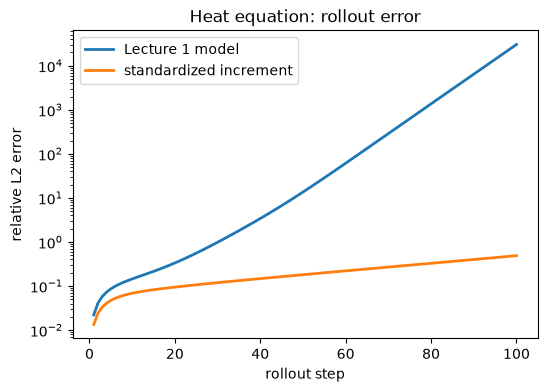

In [13]:
def rollout_errors(model, trajs):
    model.eval()
    errors = []
    with torch.no_grad():
        for traj in trajs:
            u = torch.from_numpy(traj[0]).reshape(1, 1, N, N).to(device)
            preds = []
            for n in range(T):
                u = model(u)
                preds.append(u.cpu().numpy()[0, 0])
            errors.append([relative_error(preds[n], traj[n + 1]) for n in range(T)])
    return np.mean(errors, axis=0)

def one_step_error(model, trajs):
    model.eval()
    with torch.no_grad():
        inputs = torch.from_numpy(trajs[:, :-1].reshape(-1, 1, N, N)).to(device)
        pred = model(inputs).cpu().numpy()
    return relative_error(pred, trajs[:, 1:].reshape(-1, 1, N, N))

for name, model in [("Lecture 1 model", baseline), ("standardized increment", standardized)]:
    print(f"{name:24s} one-step relative error {one_step_error(model, heat_test):.2e}")

steps = np.arange(1, T + 1)
plt.figure(figsize=(6, 4))
plt.semilogy(steps, rollout_errors(baseline, heat_test), lw=2, label="Lecture 1 model")
plt.semilogy(steps, rollout_errors(standardized, heat_test), lw=2, label="standardized increment")
plt.xlabel("rollout step"); plt.ylabel("relative L2 error"); plt.title("Heat equation: rollout error")
plt.legend(); plt.show()

**What to observe**

* The standardized model has the lower one-step error, about half that of the Lecture 1 model in our runs.
* Five epochs is short, and the rollout changes from run to run. In most of our runs the Lecture 1 model's rollout blew up (error above 100%),
  while the standardized model stayed bounded. Try another seed: change `torch.manual_seed(0)` to `1` or `2` before training.
* Late in the rollout the field has decayed toward zero, so the relative error grows for both models.

---
## Exercises

1. **Coarser grid.** Repeat Part 1 with `f = 16` (a 32 × 32 grid). How does the aliased energy change, and why?
2. **POD across conditions.** Compute POD modes from the Twall = 100 °C file and use them to reconstruct the frame from the 106 °C file used in Part 2.
   Compare the errors with those from the 106 °C modes. What does this say about using POD modes from one run on another?
3. **Unseen frequencies, again.** In Lecture 1, Exercise 3 trained on `K = 3` and tested on `K = 6`. Compute POD modes from `K = 3` heat data
   (use `heat_trajectory(K=3)`) and reconstruct `K = 6` test frames with them. Plot the error against time along a trajectory. Where does it concentrate, and why?
4. **Standardized increment for BubbleML.** For the Lecture 1 BubbleML temperature, the std of $\Delta T$ is about 56% of the std of $T$.
   Train the BubbleML model of Lecture 1 with and without the standardized increment. Do you expect as large a difference as for the heat data?